<a href="https://colab.research.google.com/github/ackuyucu/Ekoloji_Lab/blob/main/Orneklem_yontemleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

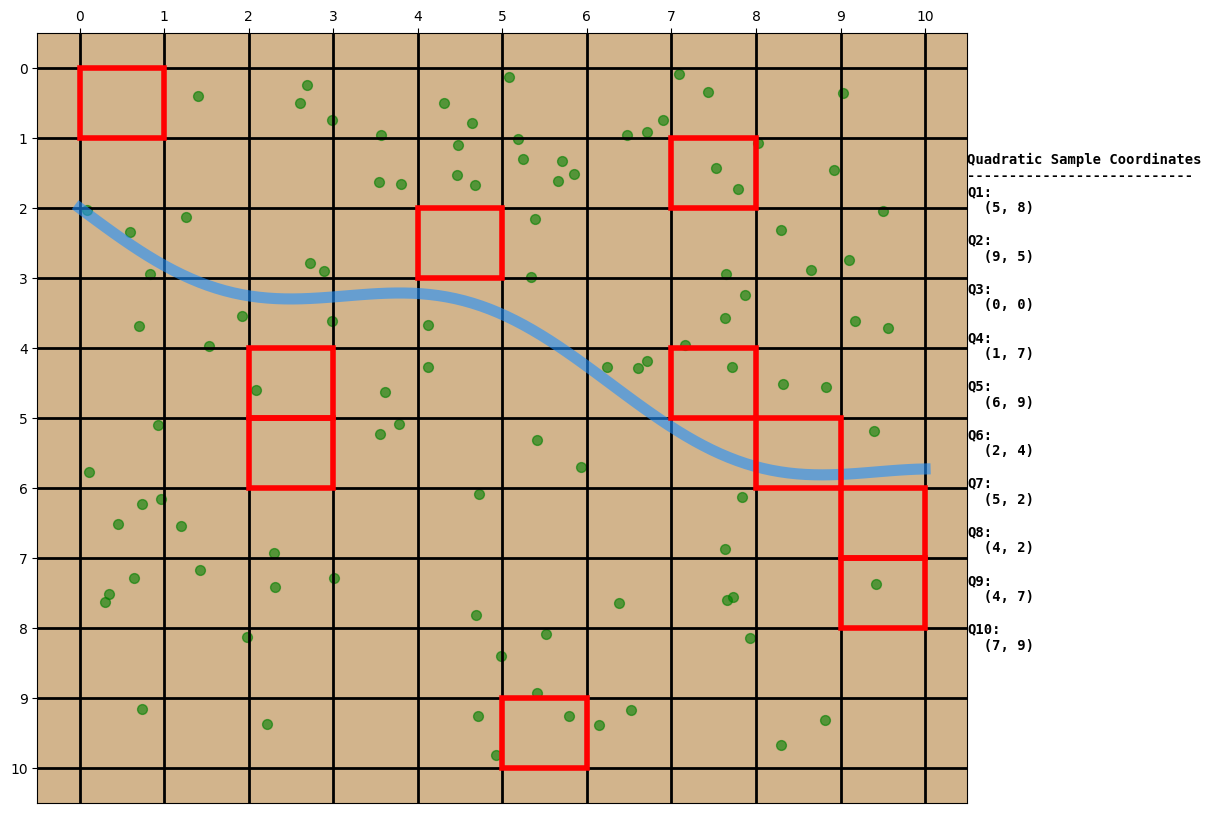

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Setup ---
np.random.seed(1)
GRID_SIZE = 10

# --- User Input for Sampling Method ---
sampling_method = 'quadratic' # @param ['quadratic', 'transect', 'vertical_transect'] {type:'string'}

# --- Sampling Logic ---
all_transects = []
list_str_title = ""

if sampling_method == 'transect':
    num_transects = 3
    transect_length = 5
    list_str_title = "Transect Coordinates\n-------------------\n"

    # 1. Pick 3 starting numbers
    starts = np.random.choice(range(1, 101), num_transects, replace=False)

    def get_coords(n):
        if n == 100: return 0, 0
        s = f"{n:02d}"
        return int(s[0]), int(s[1]) # returns Y, X

    # 2. Generate the full transect paths
    for s in starts:
        y, x = get_coords(s)
        path = []
        curr_y, curr_x = y, x

        # Always add the starting point
        path.append((curr_y, curr_x))

        for _ in range(transect_length - 1): # Generate remaining points
            curr_x = (curr_x + 1) % GRID_SIZE # Wrap around X-axis
            if curr_x == 0: # If X wrapped around, increment Y and wrap if needed
                curr_y = (curr_y + 1) % GRID_SIZE
            path.append((curr_y, curr_x))
        all_transects.append({'start': s, 'path': path})

elif sampling_method == 'quadratic':
    num_quadratic_samples = 10
    list_str_title = "Quadratic Sample Coordinates\n---------------------------\n"

    # Generate 10 random coordinates for single squares
    for i in range(num_quadratic_samples):
        y = np.random.randint(0, GRID_SIZE)
        x = np.random.randint(0, GRID_SIZE)
        # Each quadratic sample is a 'transect' of length 1
        all_transects.append({'start': f'Q{i+1}', 'path': [(y, x)]})

elif sampling_method == 'vertical_transect':
    num_transects = 3
    transect_length = 5
    list_str_title = "Vertical Transect Coordinates\n---------------------------\n"

    # 1. Pick 3 starting numbers
    starts = np.random.choice(range(1, 101), num_transects, replace=False)

    def get_coords(n):
        if n == 100: return 0, 0
        s = f"{n:02d}"
        return int(s[0]), int(s[1]) # returns Y, X

    # 2. Generate the full transect paths
    for s in starts:
        y, x = get_coords(s)
        path = []
        curr_y, curr_x = y, x

        # Always add the starting point
        path.append((curr_y, curr_x))

        for _ in range(transect_length - 1): # Generate remaining points
            curr_y = (curr_y + 1) % GRID_SIZE # Wrap around Y-axis
            if curr_y == 0: # If Y wrapped around, increment X and wrap if needed
                curr_x = (curr_x + 1) % GRID_SIZE
            path.append((curr_y, curr_x))
        all_transects.append({'start': s, 'path': path})


# --- Visualization ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#D2B48C')

# Grid and Labels
ax.set_xticks(np.arange(GRID_SIZE + 1))
ax.set_yticks(np.arange(GRID_SIZE + 1))
ax.grid(color='black', linewidth=2)
ax.set_xticklabels(range(GRID_SIZE + 1)); ax.set_yticklabels(range(GRID_SIZE + 1))
ax.invert_yaxis() # Ensure 0 is at top
ax.xaxis.tick_top() # Move X labels to top per birdview style

# Plot River (Simulated)
rx = np.linspace(0, 10, 100)
ry = 2 + 0.5 * np.sin(rx) + 0.4 * rx
ax.plot(rx, ry, color='#1E90FF', linewidth=8, alpha=0.6)

# Plot Trees (randomly distributed green points)
num_trees = 100 # You can adjust the number of trees
tree_x = np.random.uniform(0, GRID_SIZE, num_trees)
tree_y = np.random.uniform(0, GRID_SIZE, num_trees)
ax.scatter(tree_x, tree_y, color='green', marker='o', s=50, alpha=0.6, label='Trees')

# Plot Samples (Quadratic or Transect)
prominent_linewidth = 4 # Increased prominence
outline_color = 'red' # Changed to simple red

list_str = list_str_title

for i, t in enumerate(all_transects):
    # For quadratic sampling, the 'start' will be like 'Q1', 'Q2', etc.
    # For transect sampling, it will be the starting number.
    list_str += f"{t['start']}:\n"
    for (y, x) in t['path']:
        # Draw colored outline for each cell in the sample with zorder to ensure it's on top
        rect = patches.Rectangle((x, y), 1, 1, linewidth=prominent_linewidth, edgecolor=outline_color, facecolor='none', zorder=10)
        ax.add_patch(rect)
        list_str += f"  ({y}, {x})\n"
    list_str += "\n"

plt.text(10.5, 5, list_str, family='monospace', va='center', fontweight='bold')
plt.show()